# Brazilian E-Commerce Market Analysis for Turkish e-commerce platform

**Student:** Selin Hacıoğlu - GH1045279  
**Programme:** MSc Data Science, AI and Digital Business  
**Module:** M504 AI and Applications  
**University:** GISMA University of Applied Sciences  
**Date:** May 2026  
**Dataset URL:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


HER BİR GRAFİĞİ NEDEN SEÇTİĞİNİ BELİRT VEYA BELİRTİLMESİ İSTENİYOR MU KONTROL ETTİR.

# 1. Introduction

E-commerce, which refers to the process of buying and selling products and services online, has become one of the key points of the global market. Latin America has become one of the fastest-growing digital markets (McKinsey & Company, 2025; eMarketer, 2025). Brazil, which accounts for approximately 40% of the regional e-commerce market, offers an attractive opportunity for international growth (Market Data Forecast, 2026). However, entering a new market requires an understanding of local consumer behavior, operational challenges, and competitive dynamics (Laudon & Traver, 2023; Deloitte, 2024).

This analysis examines the Brazilian e-commerce environment from the perspective of a Turkish e-commerce platform planning to enter the Latin American market. The dataset includes real e-commerce data from Olist, one of Brazil’s largest marketplaces, covering over 100,000 orders. This comprehensive dataset covers all 27 states in Brazil and addresses parameters such as customer characteristics, product categories, payment behaviors, delivery performance, and customer satisfaction.

The Brazilian market was selected for its behavioral similarities with Turkey, like the culture of installment payments and mobile-first shopping habits (dLocal, 2023; J.P. Morgan, n.d.). In addition to this Brazilian market also sellected its role as a door to the large and growing middle class and the broader Latin American region . The data set covering the 2016–2018 period but it reflects key market dynamics such as customer locations, payment behaviors, and logistics models that display structural stability over time (Baldauf, 2024; Krumme et al., 2013). This pre-pandemic reference provides us with a basis for identifying long-term trends rather than specific anomalies related to the COVID era. Potential limitations related to the time frame are addressed in the discussion section of the study’s conclusions.

The analysis begins with an initial phase covering customer segmentation, product choices, and payment behaviors; then continues with delivery performance, shipping costs, and customer satisfaction. The final stage addresses suppliers and seasonal planning. Additionally, by synthesizing all these findings, it will be determined where the company should prioritize its efforts. In other words, the process will culminate in the identification of the parameters essential for its growth. Questions regarding these topics have been identified, and the focus has been placed on the answers to these questions. The path to be followed throughout the report is outlined below in the form of questions.

**Phase 1 – Understand the Market: Customers, Products & Payments**

1. In which states are customers and revenue concentrated within Brazilian e-commerce?
2. Which product categories generate the most revenue and demand?
3. What are the dominant payment methods, and how prevalent is installment usage?

**Phase 2 – Operational Excellence**

4. How does delivery performance vary across regions, and how reliably does the platform meet its estimated delivery times?
5. What are the freight cost dynamics and is a free shipping strategy feasible?
6. What factors drive customer review scores and where are the quality issues?

**Phase 3 – Growth Strategy**

7. What characteristics define top-performing sellers and how should the marketplace grow?
8. What seasonal demand patterns exist and when is the optimal time to launch?
9. Bringing it all together: which states represent the most attractive markets for prioritized expansion?

# 2. Business Context

## 2.1 Client Perspective 
This case study was designed for an e-commerce platform that serves as Turkey’s largest e-commerce marketplace, connecting thousands of sellers with millions of buyers. Building on its strong domestic presence, the company identified Latin America as its next strategic growth market and selected Brazil as its primary entry point.

## 2.2 Business Problem
Brazil shares many behavioral similarities with Turkey, but the company still needs data-driven answers to critical strategic questions before investing in the market.

## 2.3 Dataset

The analysis focused on the Olist Brazilian E-Commerce Public Dataset, which contains real commercial data collected from marketplace platforms. The dataset consists of 9 interconnected tables covering customers, orders, products, payments, reviews, sellers, geolocation, and category translations.

# 3. Data Exploration
## 3.1 Setup and Data Loading

The libraries used in this analysis are as follows: "pandas" for data manipulation, "numpy" for numerical operations, "matplotlib" and "seaborn" for visualization, and "datetime" for time series analysis.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter
import squarify


plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'


customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

## 3.2 Dataset Overview

The table created below summarizes the size, completeness, and quality of each dataset. This first look helps identify which tables need closer attention during the data preparation phase.

In [74]:

datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation,
    'category_translation': category_translation
}

overview = pd.DataFrame({
    'Rows': [df.shape[0] for df in datasets.values()],
    'Columns': [df.shape[1] for df in datasets.values()],
    'Missing Values': [df.isnull().sum().sum() for df in datasets.values()],
    'Duplicates': [df.duplicated().sum() for df in datasets.values()]
}, index=datasets.keys())

print("Dataset Overview:")
print(overview)

Dataset Overview:
                         Rows  Columns  Missing Values  Duplicates
customers               99441        5               0           0
orders                  99441        8            4908           0
order_items            112650        7               0           0
products                32951        9            2448           0
sellers                  3095        4               0           0
payments               103886        5               0           0
reviews                 99224        7          145903           0
geolocation           1000163        5               0      261831
category_translation       71        2               0           0


## 3.3 Data Quality Assessment

Tables containing missing values were examined in more detail, revealing the following findings.

When orders were reviewed, it was observed that missing values were concentrated in columns related to delivery. This is considered normal because some orders have been canceled, shipped, or are currently being processed.

Looking at the products, it was observed that 610 products (1.9%) were missing category names and metadata. This number is below the generally accepted 5% threshold at which missing data can negatively impact analytical results (Srijan & Rajagopalan, 2024). Additionally, information regarding physical measurements was missing for only two products. In conclusion, there are no issues that would negatively impact the results.

Finally, a significant portion of the reviews are without comments (87,656 missing titles; 58,247 missing messages). The fact that many customers provide only a star rating without leaving a written review indicates that this is typical user behavior. The numerical “review_score” column is completely intact and sufficient for our analysis.

These patterns are consistent with realistic e-commerce data and do not show any signs of data corruption. Each of the issues mentioned above is addressed in the next data preparation phase.

In [75]:
print("Missing Values - Orders Table:")
print(orders.isnull().sum())

print("\nMissing Values - Products Table:")
print(products.isnull().sum())

print("\nMissing Values - Reviews Table:")
print(reviews.isnull().sum())

Missing Values - Orders Table:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values - Products Table:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing Values - Reviews Table:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


### 3.4 Key Data Observations

Before the data preprocessing stage, several important characteristics were identified within the dataset. The dataset covers all 27 states of Brazil, providing us with the opportunity to perform a nationwide analysis. The presence of 99,441 orders and 112,650 order items points to the fact that many orders contain multiple products . The fact that there are only 96,096 unique customers compared to 99,441 customer IDs clearly indicates that approximately 3,345 customers are repeat buyers. On the product side, 32,951 products are spread across 72 different categories. In the payments table, the fact that there are 103,886 records for 99,441 orders indicates that multiple payment methods were used for certain orders. Finally, the presence of 99,224 review records shows that nearly every order has been rated, and it is highlighting the existence of a strong customer feedback culture.

### 3.5 Data Preprocessing

All transformations are applied to working copies of the loaded dataframes, leaving the original CSVs and the initially loaded data untouched. The following preprocessing steps were applied to prepare the data for analysis:

**1- Date conversion:** All date columns in the order and review tables were converted from string format to datetime format for temporal analysis.

**2- Category translation:** Product category names were translated from Portuguese to English using the provided translation table.

**3- Missing categories:** 623 products without category names were labeled as “unknown” to be retained in the dataset without introducing bias.

**4- Missing dimensions:** Two products with missing weight and dimension values were imputed with median values to prevent data loss in shipping cost analysis.All transformations were applied to copies of the uploaded data frames; this means that no changes were made to the original CSV files or the data initially uploaded. The following preprocessing steps were applied to prepare the data for analysis:

**5- Missing delivery dates:** Orders without delivery dates are representing orders that have not yet been delivered (cancelled, in progress, etc.). These records are saved with a NaT (Not a Time) value and are filtered out during delivery-focused analyses.

**6- Missing review comments:** Approximately 59% of reviews do not have written comments. Since numerical rating data is complete and sufficient for satisfaction analysis, no further action is required in this regard. 

**7- Duplicate geographic locations:** There were multiple coordinate records for the same ZIP code prefix, 261,831 duplicate rows were removed from the geographic location table.


In [76]:

orders = orders.copy()
reviews = reviews.copy()
products = products.copy()
geolocation = geolocation.copy()

date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])


products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')


dimension_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dimension_cols:
    products[col] = products[col].fillna(products[col].median())


geo_before = len(geolocation)
geolocation = geolocation.drop_duplicates()
geo_after = len(geolocation)


print("Preprocessing completed successfully.\n")
print(f"Date range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")
print(f"Product categories: {products['product_category_name_english'].nunique()} unique")
print(f"Unknown categories: {(products['product_category_name_english'] == 'unknown').sum()}")
print(f"Missing dimensions: {products[dimension_cols].isnull().sum().sum()}")
print(f"Geolocation: {geo_before:,} → {geo_after:,} rows ({geo_before - geo_after:,} duplicates removed)")
print(f"\nOrder status distribution:")
print(orders['order_status'].value_counts())

Preprocessing completed successfully.

Date range: 2016-09-04 to 2018-10-17
Product categories: 72 unique
Unknown categories: 623
Missing dimensions: 0
Geolocation: 1,000,163 → 738,332 rows (261,831 duplicates removed)

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### 3.6 Data Preparation for Analysis

After completing the preprocessing steps, the tables were consolidated and basic calculations were performed for use in the analysis phase. In this step, the order, customer, product, and order line tables were consolidated into a single master table; customer and revenue analysis at the state level was prepared; and a customer loyalty classification was created.

In [77]:
customer_orders = orders.merge(customers, on='customer_id') \
                        .merge(order_items, on='order_id') \
                        .merge(products, on='product_id')

state_analysis = customer_orders.groupby('customer_state').agg(
    customer_count=('customer_unique_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_revenue', ascending=False)

customer_orders_count = customer_orders.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_spent=('price', 'sum')
).reset_index()

customer_orders_count['customer_type'] = customer_orders_count['order_count'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-Time'
)

customer_with_type = customer_orders.merge(
    customer_orders_count[['customer_unique_id', 'customer_type']], 
    on='customer_unique_id'
)

print(f"Master table: {len(customer_orders):,} rows")
print(f"Unique customers: {customer_orders['customer_unique_id'].nunique():,}")
print(f"One-Time: {(customer_orders_count['customer_type']=='One-Time').sum():,}")
print(f"Repeat: {(customer_orders_count['customer_type']=='Repeat').sum():,}")

Master table: 112,650 rows
Unique customers: 95,420
One-Time: 92,507
Repeat: 2,913


## 4. Exploratory Data Analysis

### Phase 1: Understanding the Market: Customers, Products, and Payments

Before entering a new market, it is important to understand who are the customers , what they buy, and how they make payments. This step will form the basis for the next strategic decisions.

### 4.1 Question 1: In which states are customers and revenue concentrated within Brazilian e-commerce?

Business Importance: Understanding the geographic distribution of existing customers and their loyalties directly shapes decisions regarding launch locations, marketing budget, and priority customer segments. A market where demand is concentrated in a few specific regions requires a different entry strategy.

This analysis examines customers from two perspectives: First one is geographic concentration at the state and city levels; and second one is the loyalty behaviors and geographic distribution of one-time buyers compared to repeat customers.

#### 4.1.1 Geographic Distribution: State and City Levels

As a first step, it is crucial to understand where customers and revenue are located. The three charts below show the distribution of customer numbers and revenue at the state level, followed by revenue rankings at the city level. By moving from the general to the specific, it becomes clear exactly which areas efforts should be focused on.

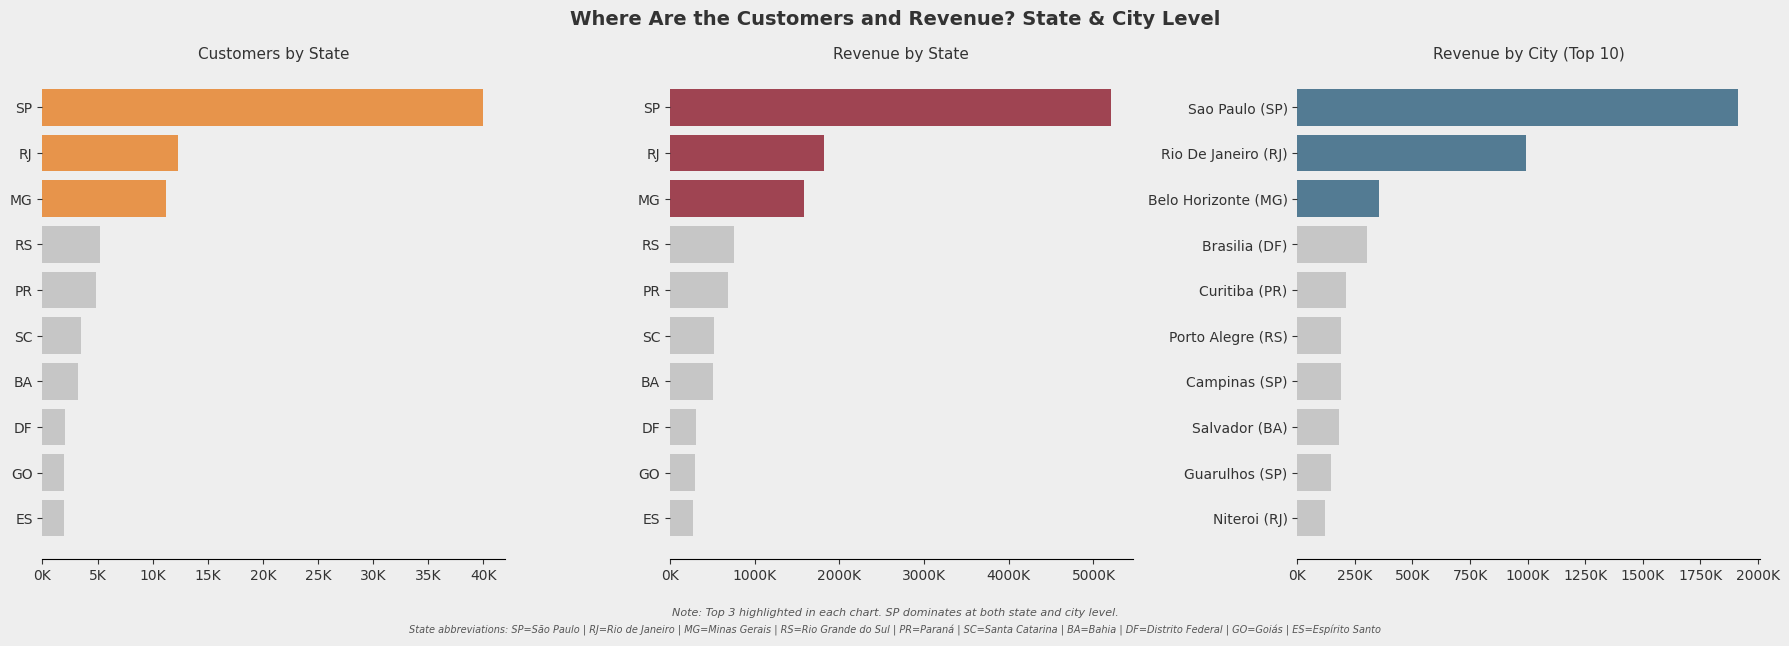

In [78]:
top10 = state_analysis.head(10)

city_revenue = customer_orders.groupby(['customer_city', 'customer_state'])['price'].sum()
city_revenue = city_revenue.sort_values(ascending=False).head(10)
city_labels = [f"{city.title()} ({state})" for city, state in city_revenue.index]

customer_colors = ['#E67E22']*3 + ['#BDBDBD']*7
revenue_colors = ['#8B1A2B']*3 + ['#BDBDBD']*7
city_colors = ['#2C5F7C']*3 + ['#BDBDBD']*7

fig, (axConsumers, axrevenue, axrevenue_10) = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#EEEEEE')
for ax in [axConsumers, axrevenue, axrevenue_10]:
    ax.set_facecolor('#EEEEEE')

axConsumers.barh(top10.index, top10['customer_count'], color=customer_colors, alpha=0.8)
axConsumers.set_title('Customers by State', fontsize=11)
axConsumers.invert_yaxis()

axrevenue.barh(top10.index, top10['total_revenue'], color=revenue_colors, alpha=0.8)
axrevenue.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axrevenue.set_title('Revenue by State', fontsize=11)
axrevenue.invert_yaxis()

axrevenue_10.barh(city_labels, city_revenue.values, color=city_colors, alpha=0.8)
axrevenue_10.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axrevenue_10.set_title('Revenue by City (Top 10)', fontsize=11)
axrevenue_10.invert_yaxis()

axConsumers.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
axrevenue.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
axrevenue_10.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

for ax in [axConsumers, axrevenue, axrevenue_10]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

fig.suptitle('Where Are the Customers and Revenue? State & City Level', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.03, 
         'Note: Top 3 highlighted in each chart. SP dominates at both state and city level.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')
fig.text(0.5, -0.06, 
         'State abbreviations: SP=São Paulo | RJ=Rio de Janeiro | MG=Minas Gerais | RS=Rio Grande do Sul | PR=Paraná | SC=Santa Catarina | BA=Bahia | DF=Distrito Federal | GO=Goiás | ES=Espírito Santo',
         ha='center', fontsize=7, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The Brazilian e-commerce market is largely concentrated in the Southeast region. Sao Paulo (SP) leads by a wide margin in terms of both the number of customers and revenue, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). The majority of total revenue is focused on just the top five states. When we look at the  revenue distribution  at the city level, the same trend is visible. The city of Sao Paulo tops the list with approximately Two million Brazilian reais in revenue. Another notable finding is that while Brasília (DF) ranks 8th among the states, it ranks in the top 5 at the city level. This indicates that the capital has high purchasing power. All these results suggest that the client company should focus its operations on the Southeast corridor rather than expanding nationwide.

#### 4.1.2 Customer Loyalty: One-Time and Repeat Buyers

While knowing customers’ geographic locations is important, understanding their loyalty behaviors is equally critical. It is well known in the literature that attracting new customers is significantly more costly than keeping existing ones. This analysis compares one time buyers with repeat customers in terms of number, average spending, and geographic distribution.

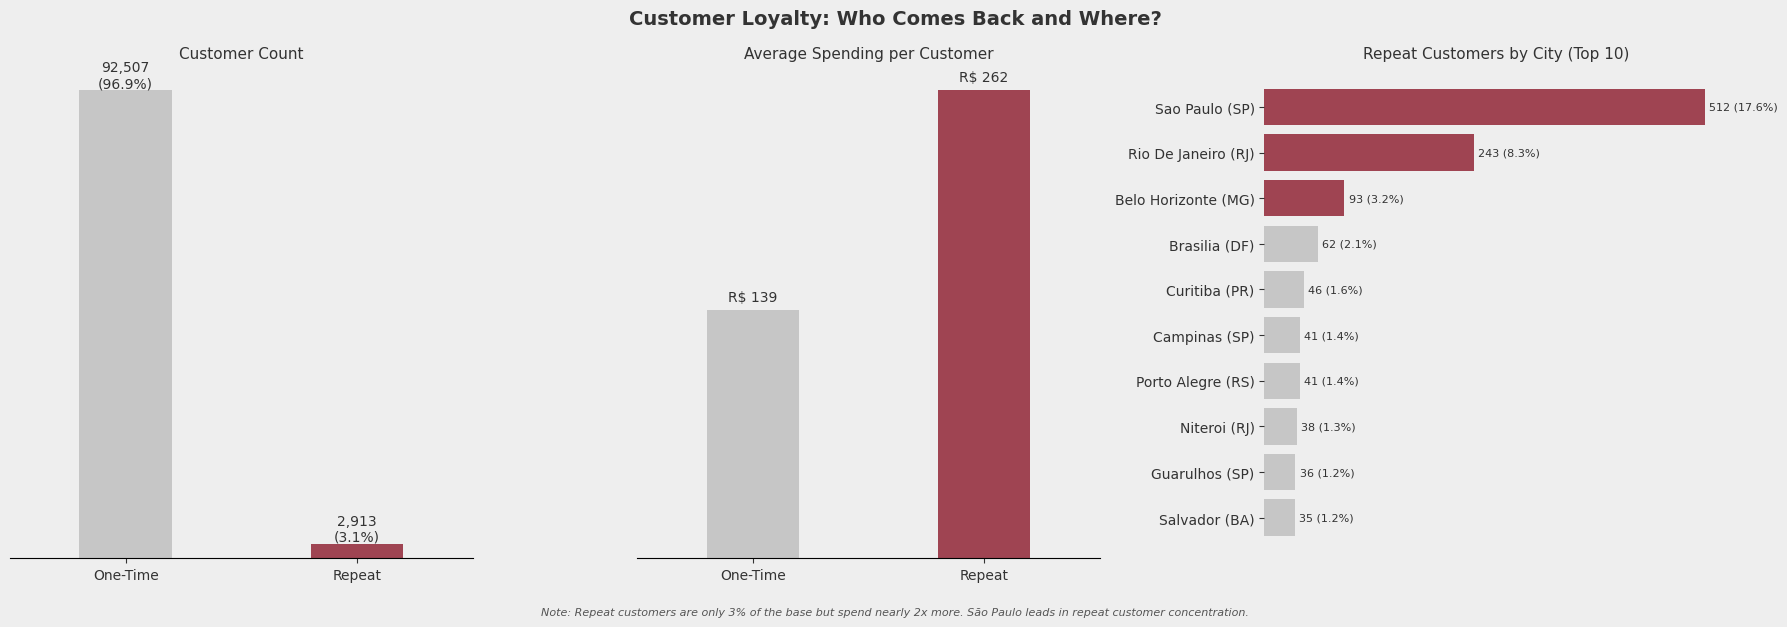

In [79]:

repeat_by_city = customer_with_type[
    customer_with_type['customer_type'] == 'Repeat'
].groupby(['customer_city', 'customer_state'])['customer_unique_id'].nunique()
repeat_by_city = repeat_by_city.sort_values(ascending=False).head(10)
total_repeat = customer_with_type[customer_with_type['customer_type'] == 'Repeat']['customer_unique_id'].nunique()
city_labels = [f"{city.title()} ({state})" for city, state in repeat_by_city.index]


type_summary = customer_orders_count.groupby('customer_type').agg(
    customers=('customer_unique_id', 'count'),
    avg_spent=('total_spent', 'mean')
)
total_customers = type_summary['customers'].sum()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#EEEEEE')
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#EEEEEE')

colors = ['#BDBDBD', '#8B1A2B']


barscustomer = ax1.bar(type_summary.index, type_summary['customers'], color=colors, width=0.4, alpha=0.8)
ax1.set_title('Customer Count', fontsize=11)
for bar, val in zip(barscustomer, type_summary['customers']):
    pct = val / total_customers * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)


barsSpending = ax2.bar(type_summary.index, type_summary['avg_spent'], color=colors, width=0.4, alpha=0.8)
ax2.set_title('Average Spending per Customer', fontsize=11)
for bar, val in zip(barsSpending, type_summary['avg_spent']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'R$ {val:,.0f}', ha='center', fontsize=10)


city_colors = ['#8B1A2B']*3 + ['#BDBDBD']*7
ax3.barh(city_labels, repeat_by_city.values, color=city_colors, alpha=0.8)
ax3.invert_yaxis()
ax3.set_title('Repeat Customers by City (Top 10)', fontsize=11)
for i, val in enumerate(repeat_by_city.values):
    pct = val / total_repeat * 100
    ax3.text(val + 5, i, f'{val} ({pct:.1f}%)', va='center', fontsize=8)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_xlim(-0.5, 1.5)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_xticks([])

fig.suptitle('Customer Loyalty: Who Comes Back and Where?', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.03, 
         'Note: Repeat customers are only 3% of the base but spend nearly 2x more. São Paulo leads in repeat customer concentration.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The results show a remarkable pattern. Most customers (92,507) are one time buyers, while only 2,913 customers approximately 3% have made repeat purchases. However, repeat customers spend nearly twice as much on an average purchase. In terms of geographic distribution, repeat customers are again concentrated in Sao Paulo, Rio de Janeiro, and Belo Horizonte, confirming the general market concentration shown in the first figure.

The findings from the charts provide important strategic insights. While attracting new customers is critical during the market entry phase, creating a loyalty program in the early stages can increase customer lifetime value. The low repeat purchase rate also presents an opportunity. Even the slightest improvement in this metric will have a significant impact on sales.

### 4.2 Question 2: Which product categories generate the most revenue and demand?

**Business Significance:** Once you understand the customer profile and geographic distribution, the next question to answer is what these customers are buying. Knowing which categories generate the most revenue and which have the highest sales volume directly shapes decisions about initial inventory, supplier partnerships, and marketing strategy.

This analysis examines product categories from two perspectives: Fİrst one is revenue distribution and second one is the combined evaluation of order volume and average price.

#### 4.2.1 Revenue Distribution by Category

The treemap below visualizes the distribution of total revenue across product categories. Larger boxes represent a higher share of revenue.


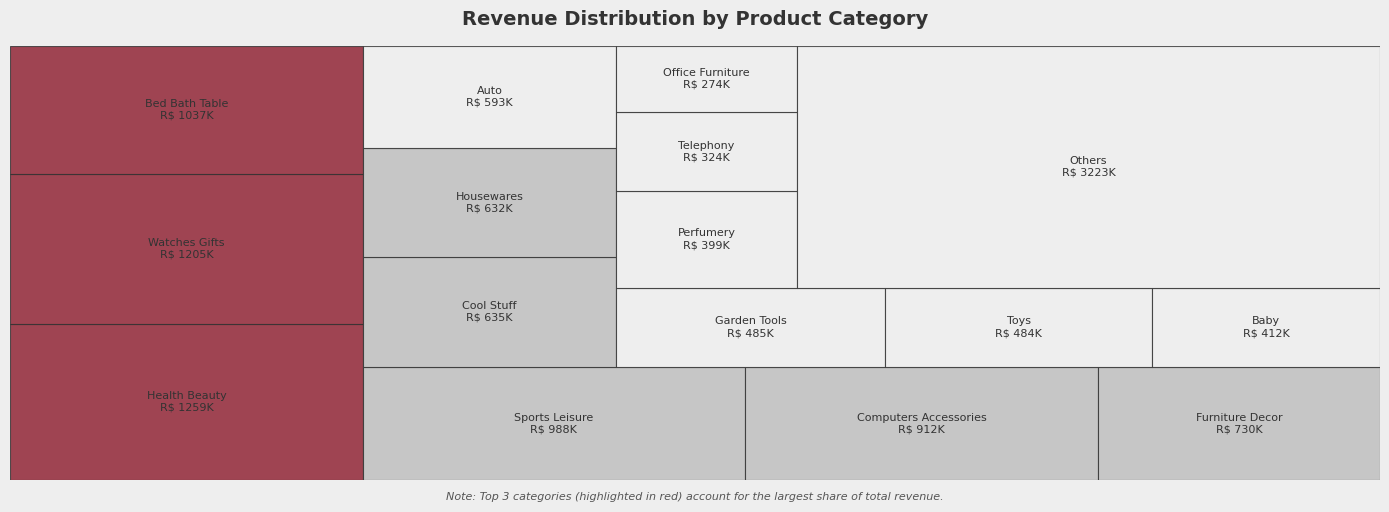

In [80]:

category_analysis = customer_orders.groupby('product_category_name_english').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).sort_values('total_revenue', ascending=False)

top15 = category_analysis.head(15)
others_revenue = category_analysis.iloc[15:]['total_revenue'].sum()

treemap_data = pd.concat([top15['total_revenue'], 
                          pd.Series({'others': others_revenue})])

labels = [f"{name.replace('_', ' ').title()}\nR$ {val/1000:.0f}K" for name, val in treemap_data.items()]
colors = ['#8B1A2B']*3 + ['#BDBDBD']*5 + ['#EEEEEE']*8

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#EEEEEE')
ax.set_facecolor('#EEEEEE')

squarify.plot(sizes=treemap_data.values, label=labels, color=colors, 
              alpha=0.8, text_kwargs={'fontsize': 8}, ax=ax,
              edgecolor='#333333', linewidth=0.8)

ax.set_title('Revenue Distribution by Product Category', 
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

fig.text(0.5, -0.01, 
         'Note: Top 3 categories (highlighted in red) account for the largest share of total revenue.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The treemap shows that revenue is concentrated in specific categories. Health Beauty (R$ 1,259K), Watches Gifts (R$ 1,205K), and Bed Bath Table (R$ 1,037K) stand out as the top three revenue-generating categories. These top three categories alone represent a significant portion of total revenue, while the remaining categories have relatively smaller shares. This concentration suggests that focusing on a limited number of categories during the market entry phase is a rational strategy.

#### 4.2.2 Order Volume and Average Price by Category

While the treemap shows where revenue is concentrated, it does not reveal whether a category stands out because it has a high number of orders or because of its high price. The following dual-axis chart combines these two dimensions. The bars show the number of orders, while the orange line indicates the average price per category.


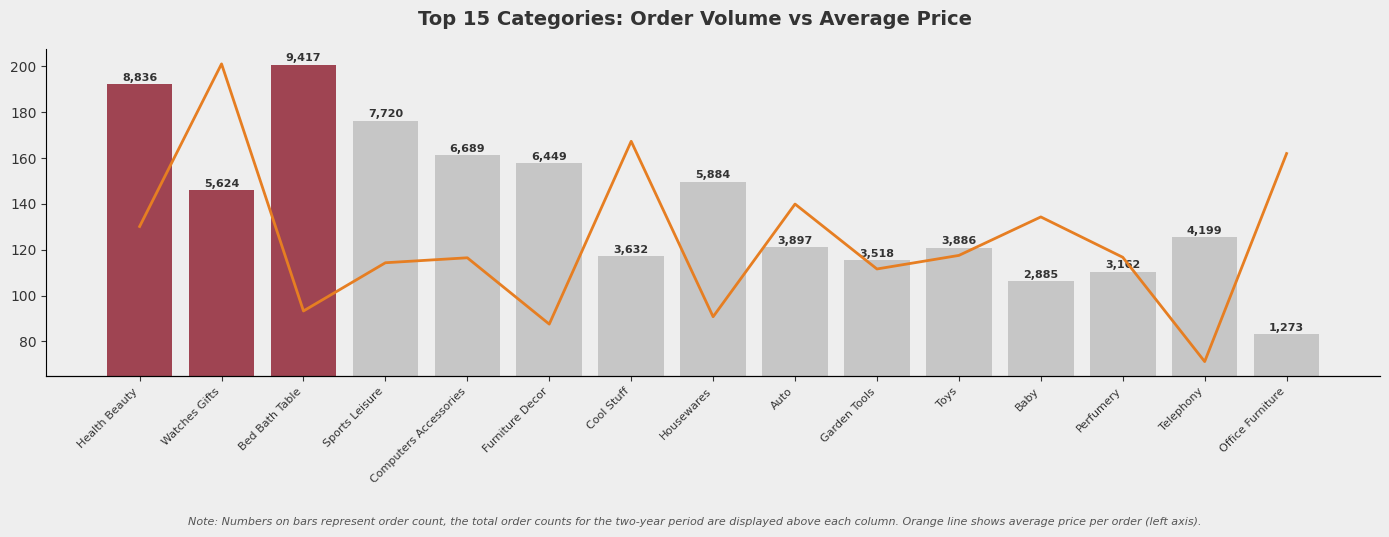

In [81]:

top15_dual = category_analysis.head(15)

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')


bar_colors = ['#8B1A2B']*3 + ['#BDBDBD']*12
bars = ax1.bar(range(len(top15_dual)), top15_dual['order_count'], color=bar_colors, alpha=0.8)


for i, val in enumerate(top15_dual['order_count']):
    ax1.text(i, val + 100, f'{val:,}', ha='center', fontsize=8, fontweight='bold')


ax1.set_yticks([])
ax1.set_ylabel('')

ax1.set_xticks(range(len(top15_dual)))
ax1.set_xticklabels([name.replace('_', ' ').title() for name in top15_dual.index], 
                     rotation=45, ha='right', fontsize=8)


ax2 = ax1.twinx()
ax2.plot(range(len(top15_dual)), top15_dual['avg_price'], color='#E67E22', 
         linewidth=2)
ax2.yaxis.set_label_position('left')
ax2.yaxis.tick_left()


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Top 15 Categories: Order Volume vs Average Price', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.05, 
         'Note: Numbers on bars represent order count, the total order counts for the two-year period are displayed above each column. Orange line shows average price per order (left axis).',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

This chart reveals important details. Health Beauty and Bed Bath and Table lead in both order volume and revenue, confirming massive market demand. Watches and Gifts, despite having fewer orders, point to a premium segment due to their high average price. Categories like Cool Stuff and Office Furniture have low volume but the highest average prices. Housewares, on the other hand, represents a price-sensitive consumer base with high volume but low price points.

### 4.3 Question 3: What are the dominant payment methods, and how prevalent is installment usage?

**Business Importance:** Payment preferences can be considered one of the critical components of any market entry strategy because they directly determine the payment infrastructure the platform must establish, its financing partnerships, and its pricing approaches. In other words, understanding payment methods in Brazil is of critical importance for shaping competitive offerings and managing financial risk.

This analysis examines payment behavior from two perspectives. The first is the general distribution of payment methods used by customers, followed by an examination of credit card users’ installment preferences.

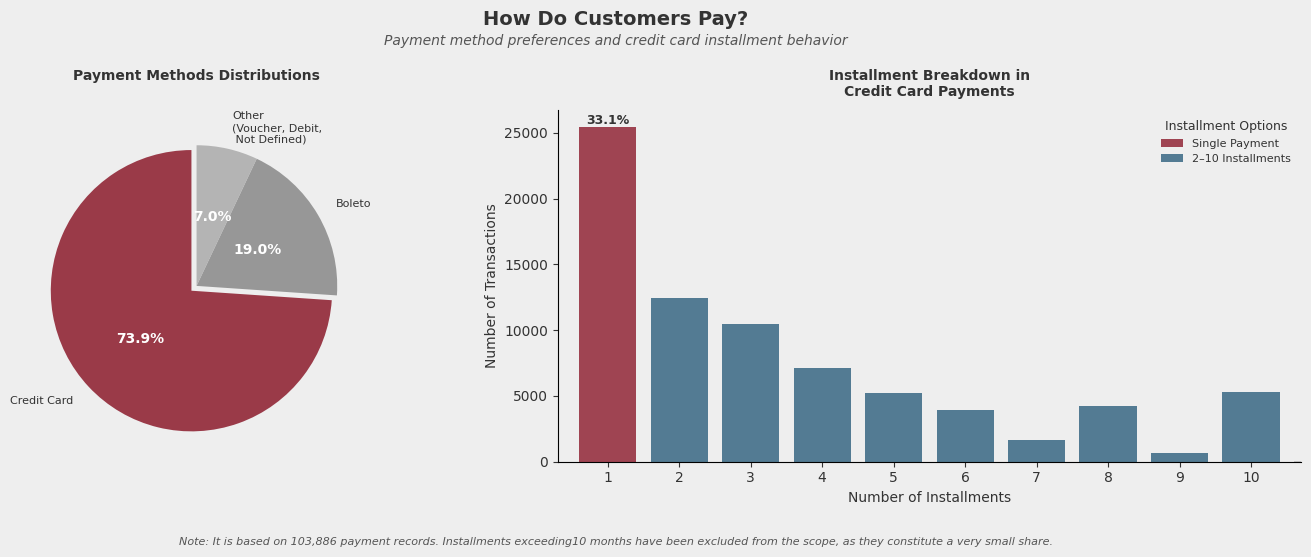

In [82]:

payment_dist = payments['payment_type'].value_counts()
main_payments = pd.Series({
    'Credit Card': payment_dist.get('credit_card', 0),
    'Boleto': payment_dist.get('boleto', 0),
    'Other': payment_dist.get('voucher', 0) + payment_dist.get('debit_card', 0) + payment_dist.get('not_defined', 0)
})

pie_colors = ['#8B1A2B', '#888888', '#AAAAAA']
explode = [0.05, 0, 0]

# Installment data
cc_payments = payments[(payments['payment_type'] == 'credit_card') & (payments['payment_installments'] > 0)]
installment_counts = cc_payments['payment_installments'].value_counts().sort_index()
installment_counts_trimmed = installment_counts[installment_counts.index <= 12]

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [0.5, 0.7]})
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('How Do Customers Pay?', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.95, 'Payment method preferences and credit card installment behavior', 
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Pie chart
wedges, texts, autotexts = ax1.pie(
    main_payments.values,
    labels=['Credit Card', 'Boleto', 'Other\n(Voucher, Debit,\n Not Defined)'],
    autopct='%1.1f%%',
    colors=pie_colors,
    pctdistance=0.5,
    labeldistance=1.15,
    startangle=90,
    explode=explode,
    wedgeprops=dict(alpha=0.85)
)

for text in texts:
    text.set_fontsize(8)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_color('white')

ax1.set_title('Payment Methods Distributions\n', fontsize=10, fontweight='bold', pad=10)


total_cc = len(cc_payments)
bar_colors = []
for x in installment_counts_trimmed.index:
    if x == 1:
        bar_colors.append('#8B1A2B')
    elif x <= 10:
        bar_colors.append('#2C5F7C')
    else:
        bar_colors.append('#BDBDBD')

ax2.bar(installment_counts_trimmed.index, installment_counts_trimmed.values, color=bar_colors, 
        alpha=0.8)


for x, val in installment_counts_trimmed.items():
    if x == 1:
        ax2.text(x, val + 200, '33.1%', ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Number of Installments')
ax2.set_ylabel('Number of Transactions')
ax2.set_xticks(range(1, 20))
ax2.set_xlim(0.3, 12.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(0.3, 10.7) 
ax2.set_title('Installment Breakdown in\nCredit Card Payments', fontsize=10, fontweight='bold', pad=10)


from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#8B1A2B', alpha=0.8, label='Single Payment'),
                   Patch(facecolor='#2C5F7C', alpha=0.8, label='2–10 Installments'),]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9, edgecolor='#EEEEEE', title='Installment Options', 
           title_fontsize=9, facecolor='#EEEEEE')

fig.text(0.5, -0.05,
         f'Note: It is based on {len(payments):,} payment records. Installments exceeding' 
         '10 months have been excluded from the scope, as they constitute a very small share.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

Based on the charts, it can be seen that credit cards are the dominant payment method in Brazil. 73.9% of all transactions are made by credit card. The Boleto, a payment slip unique to Brazil, ranks second at 19%. This percentage indicates that the category of customers with limited or no access to the banking system must also be taken into account.

Looking at the installment distribution, only 33.1% of credit card users make a one-time payment, while the remaining 66.9% prefer to pay in installments. While the most common range is 2 and 3 installments, the 10 installment option also has a significant usage rate. This shows that installment payments are a method Brazilian consumers expect when shopping online. 

These findings point to a significant strategic advantage for the client company. Turkey’s established installment infrastructure and consumer finance experience are directly transferable to the Brazilian market. Offering at least a 10 installment option and establishing installment agreements with local banks should be among the priority components of the market entry strategy. 

### Phase 2: Operational Excellence: Monitoring Delivery, Costs, and Satisfaction

After market dynamics are understood, the focus needs to shift to operational challenges. Success in e-commerce depends on the customer experience, and the customer experience is also directly linked to delivery and logistics performance. In this phase, delivery time, shipping cost, and their effect on customer satisfaction will be analyzed.

### 4.4 Question 4: How does delivery performance vary across regions, and how reliably does the platform meet its estimated delivery times?

**Business İmportance** Delivery performance is one of the most important operational factors when entering the e-commerce market. Understanding which regions receive orders quickly directly shapes decisions about warehouse locations, logistics partnerships, and service level commitments.This part examines delivery performance from two perspectives. Data on the distribution of actual delivery times in the states with the highest order volumes, as well as the reliability of estimated delivery dates at the state level across all 27 states in Brazil, is provided below.

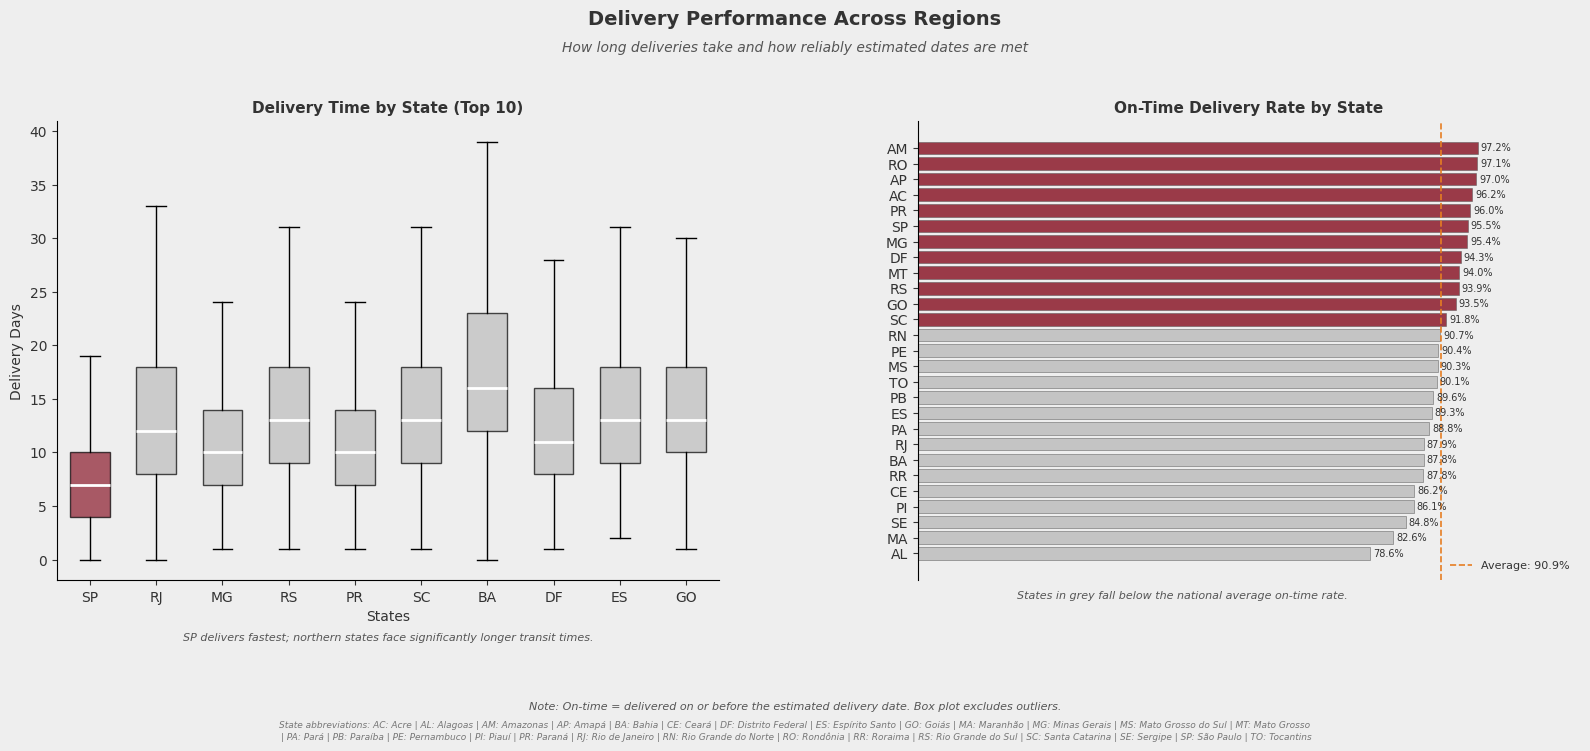

In [83]:
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['on_time'] = delivered['delay_days'] <= 0

df = delivered.merge(customers, on='customer_id')

top10 = df['customer_state'].value_counts().head(10).index
on_time_rate = df.groupby('customer_state')['on_time'].mean().mul(100).sort_values()
avg = on_time_rate.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('Delivery Performance Across Regions', fontsize=14, fontweight='bold')
fig.text(0.5, 0.92, 'How long deliveries take and how reliably estimated dates are met',
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Box plot
state_data = [df[df['customer_state'] == s]['delivery_days'].dropna() for s in top10]
bp = ax1.boxplot(state_data, labels=top10, patch_artist=True, showfliers=False, widths=0.6)

for box in bp['boxes']:
    box.set_facecolor('#BDBDBD')
    box.set_alpha(0.7)
bp['boxes'][0].set_facecolor('#8B1A2B')

for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

ax1.set_xlabel('States')
ax1.set_ylabel('Delivery Days')
ax1.set_title('Delivery Time by State (Top 10)', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.5, -0.13, 'SP delivers fastest; northern states face significantly longer transit times.',
         transform=ax1.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Right: On-time rate
colors = ['#BDBDBD' if v < avg else '#8B1A2B' for v in on_time_rate]
ax2.barh(on_time_rate.index, on_time_rate.values, color=colors, alpha=0.85, edgecolor='#555555', linewidth=0.4)
ax2.axvline(avg, color='#E67E22', linestyle='--', linewidth=1.2, label=f'Average: {avg:.1f}%')

for state, val in on_time_rate.items():
    ax2.text(val + 0.5, state, f'{val:.1f}%', va='center', fontsize=7)

ax2.set_title('On-Time Delivery Rate by State', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 115)
ax2.set_xticks([])
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.legend(fontsize=8, framealpha=0)
ax2.text(0.4, -0.04, 'States in grey fall below the national average on-time rate.',
         transform=ax2.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

fig.text(0.5, -0.02, 'Note: On-time = delivered on or before the estimated delivery date. Box plot excludes outliers.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')
state_names = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AM': 'Amazonas', 'AP': 'Amapá',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MG': 'Minas Gerais', 'MS': 'Mato Grosso do Sul',
    'MT': 'Mato Grosso\n', 'PA': 'Pará', 'PB': 'Paraíba', 'PE': 'Pernambuco',
    'PI': 'Piauí', 'PR': 'Paraná', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RO': 'Rondônia', 'RR': 'Roraima', 'RS': 'Rio Grande do Sul', 'SC': 'Santa Catarina',
    'SE': 'Sergipe', 'SP': 'São Paulo', 'TO': 'Tocantins'
}

abbreviation_note = ' | '.join([f'{k}: {v}' for k, v in state_names.items()])

fig.text(0.5, -0.06,
         f'State abbreviations: {abbreviation_note}',
         ha='center', fontsize=6.5, fontstyle='italic', color='#777777', wrap=True)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)
plt.show()

The delivery time chart highlights significant differences between states. Sao Paulo has both; the shortest median delivery time (around 7 days) and the tightest distribution. This consistency comes from the fact that the majority of sellers are based in this state. In contrast, in states such as Bahia and the Federal District, the median delivery time approaches 15 days, and variation increases significantly.

When on-time delivery rates are examined, the platform’s overall average is 90.9%. However, this average masks significant differences among states. Northern states such as Amazonas, Rondonia, and Amapa demonstrate the best performance with a timely delivery rate exceeding 97%, while Alagoas at 78.6% and Maranhao at 82.6% fall significantly below the average.

As a result, two key strategic conclusions have been drawn from the company’s perspective. First, a market entry focused on the Southeast is the least risky option from a logistics standpoint. Second, the low on-time delivery rates in the Northeast states indicate the need to invest in regional warehouses or local logistics partnerships in these

### 4.5 Question 5: What are the freight cost dynamics and is a free shipping strategy feasible?

**Business Important** Shipping costs are one of the most sensitive components of pricing strategy in e-commerce. Offering free shipping can decrease profit margins, or  failing to offer it at all may drive customers toward competitors.

For the Brazilian market, it is essential to understand what determines shipping costs and at which order values the cost can be absorbed. This is a fundamental question that must be answered before a company's pricing and promotional strategies are designed.
This section examines this topic with two aspects. One of them is the factors influencing shipping costs, and the other is how the ratio of shipping costs to price varies across different order value segments.

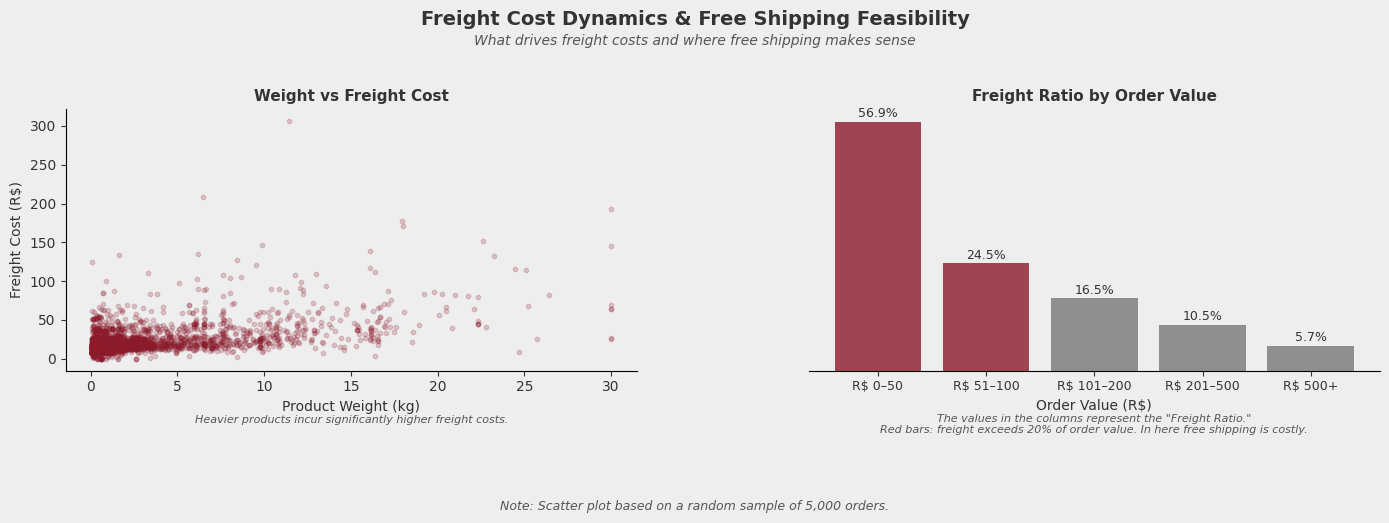

In [84]:
freight = order_items.merge(products, on='product_id').dropna(subset=['product_weight_g', 'freight_value', 'price'])
freight['freight_ratio'] = freight['freight_value'] / freight['price'] * 100
freight['price_range'] = pd.cut(freight['price'], bins=[0, 50, 100, 200, 500, 10000],
                                 labels=['0–50', '51–100', '101–200', '201–500', '500+'])

sample = freight.sample(5000, random_state=42)
freight_by_price = freight.groupby('price_range', observed=True)['freight_ratio'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('Freight Cost Dynamics & Free Shipping Feasibility', fontsize=14, fontweight='bold')
fig.text(0.5, 0.91, 'What drives freight costs and where free shipping makes sense',
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Scatter
ax1.scatter(sample['product_weight_g'] / 1000, sample['freight_value'], c='#8B1A2B', alpha=0.2, s=10)
ax1.set_xlabel('Product Weight (kg)')
ax1.set_ylabel('Freight Cost (R$)')
ax1.set_title('Weight vs Freight Cost', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.5, -0.20, 'Heavier products incur significantly higher freight costs.',
         transform=ax1.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Right: Bar
colors = ['#8B1A2B' if v > 20 else '#777777' for v in freight_by_price]
ax2.bar(range(len(freight_by_price)), freight_by_price.values, color=colors, alpha=0.8)

for i, val in enumerate(freight_by_price.values):
    ax2.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

ax2.set_xticks(range(len(freight_by_price)))
ax2.set_xticklabels([f'R$ {l}' for l in freight_by_price.index], fontsize=9)
ax2.set_xlabel('Order Value (R$)')
ax2.set_ylabel('')
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.set_yticks([])
ax2.set_title('Freight Ratio by Order Value', fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.text(0.5, -0.24, 'The values ​​in the columns represent the "Freight Ratio."\nRed bars: freight exceeds 20% of order value. In here free shipping is costly.',
         transform=ax2.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

fig.text(0.5, -0.02, 'Note: Scatter plot based on a random sample of 5,000 orders.',
         ha='center', fontsize=9, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)
plt.show()

The graph on the left shows that shipping costs rise as weight increases. However, variations in cost are evident even among products of the same weight. This suggests that factors such as distance and carrier also play a significant role.

The graph on the right, meanwhile, presents a clear picture regarding the decision to offer free shipping. For orders under 50 Brazilian Reals, shipping costs amount to nearly half of the order value. Consequently, offering free shipping in this segment is not profitable. Once the order value exceeds 100 Brazilian Reals, this ratio drops to 16.5%. For orders over 500 Brazilian Reals, it stands at just 5.7%.

In conclusion, setting the free shipping threshold within the 100 to 150 Brazilian Reais range would be a logical starting point.

### 4.6 Question 6: What factors drive customer review scores and where are the quality issues?

**Business Importance** Business Importance: After analysing delivery performance and freight costs, the next step is understanding how these factors translate into customer satisfaction. Knowing which conditions and categories generate low review scores is essential for setting service level targets, identifying problem areas, and improving the overall customer experience.
This analysis approaches the question in three steps.

First, a correlation analysis is conducted across all available variables to identify which factors have the strongest relationship with review scores. The two most significant factors are then examined in depth: delivery timing and product category performance

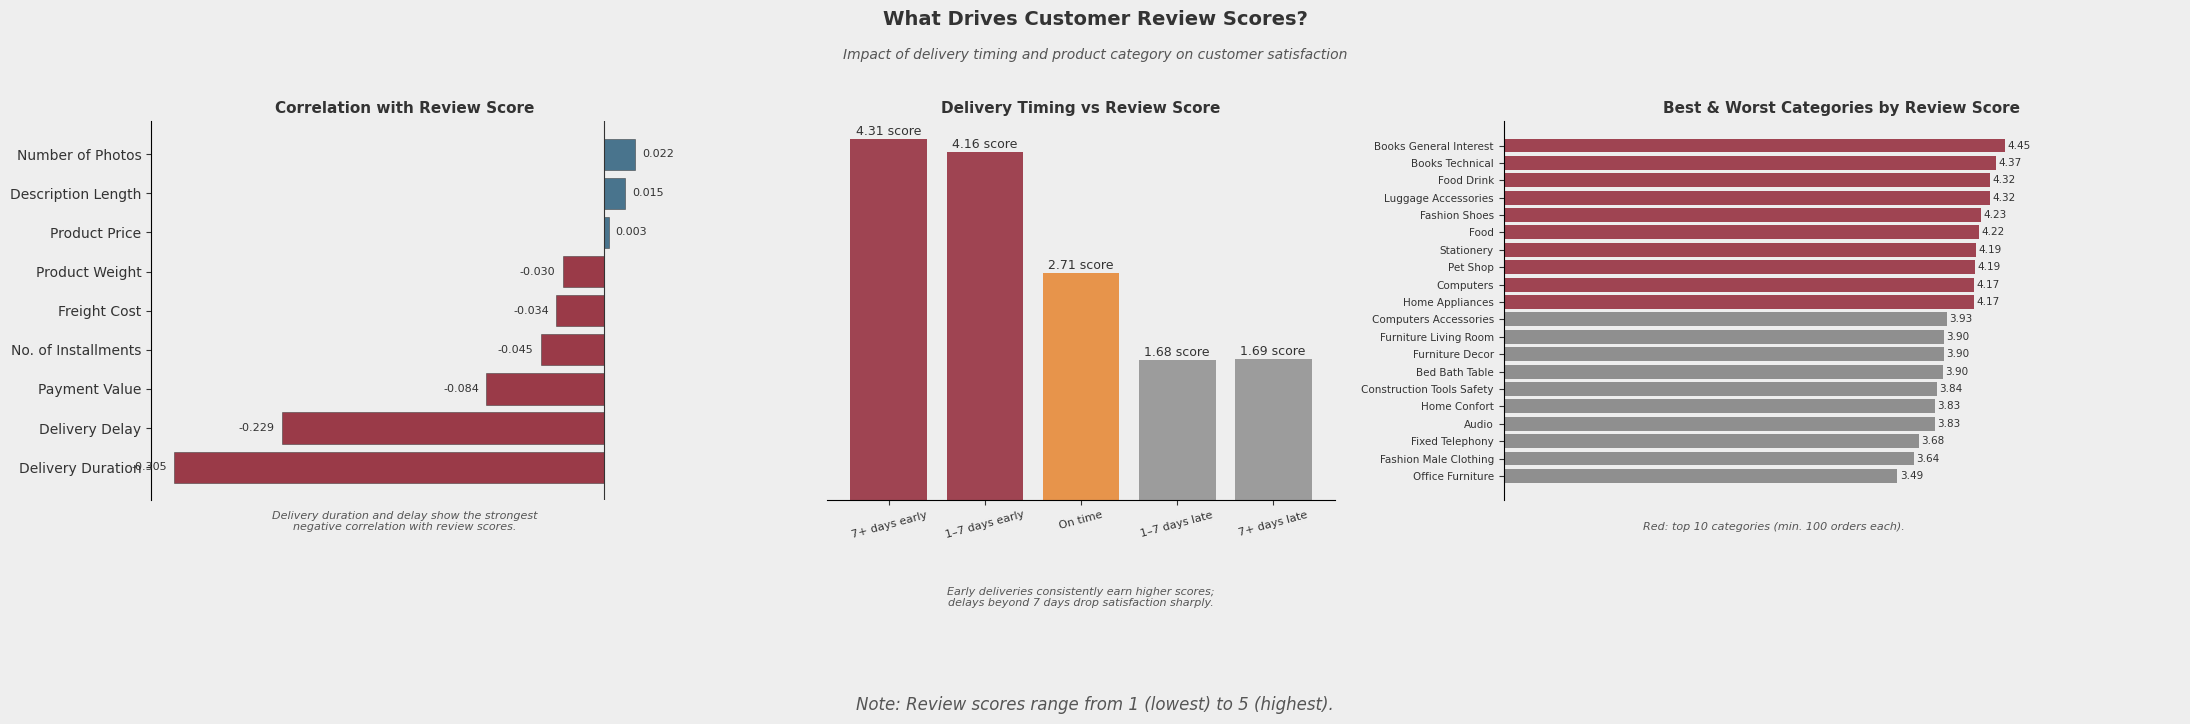

In [88]:
# Build analysis dataframe
analysis = order_items.merge(products, on='product_id') \
    .merge(orders[['order_id', 'order_purchase_timestamp',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']], on='order_id') \
    .merge(reviews[['order_id', 'review_score']], on='order_id') \
    .merge(payments.groupby('order_id').agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum')), on='order_id')

for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    analysis[col] = pd.to_datetime(analysis[col])

analysis['delivery_days'] = (analysis['order_delivered_customer_date'] - analysis['order_purchase_timestamp']).dt.days
analysis['delay_days'] = (analysis['order_delivered_customer_date'] - analysis['order_estimated_delivery_date']).dt.days

# Correlation
features = ['price', 'freight_value', 'delivery_days', 'delay_days', 'payment_installments',
            'payment_value', 'product_weight_g', 'product_description_lenght', 'product_photos_qty', 'review_score']
corr = analysis[features].dropna().corr()['review_score'].drop('review_score').sort_values()
corr_renamed = corr.rename({
    'delivery_days': 'Delivery Duration', 'delay_days': 'Delivery Delay',
    'payment_value': 'Payment Value', 'payment_installments': 'No. of Installments',
    'freight_value': 'Freight Cost', 'product_weight_g': 'Product Weight',
    'price': 'Product Price', 'product_description_lenght': 'Description Length',
    'product_photos_qty': 'Number of Photos'
})

# Delay scores
delivered['delay_category'] = pd.cut(delivered['delay_days'],
    bins=[-100, -7, 0, 7, 14, 100],
    labels=['7+ days early', '1–7 days early', 'On time', '1–7 days late', '7+ days late'])
delay_scores = delivered.merge(reviews, on='order_id').groupby('delay_category', observed=True)['review_score'].mean()

# Category scores
cat_scores = order_items.merge(products[['product_id', 'product_category_name']], on='product_id') \
    .merge(reviews[['order_id', 'review_score']], on='order_id') \
    .merge(category_translation, on='product_category_name') \
    .groupby('product_category_name_english')['review_score'].agg(['mean', 'count'])
cat_scores = cat_scores[cat_scores['count'] >= 100].sort_values('mean')
combined = pd.concat([cat_scores.head(10), cat_scores.tail(10)])

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={'width_ratios': [1.5, 1.5, 2]})
fig.patch.set_facecolor('#EEEEEE')
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#EEEEEE')

fig.suptitle('What Drives Customer Review Scores?', fontsize=14, fontweight='bold')
fig.text(0.5, 0.91, 'Impact of delivery timing and product category on customer satisfaction',
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Correlation
ax1.barh(corr_renamed.index, corr_renamed.values,
         color=['#8B1A2B' if v < 0 else '#2C5F7C' for v in corr_renamed.values], alpha=0.85, edgecolor='#333333', linewidth=0.4)
ax1.axvline(0, color='#333333', linewidth=0.8)
for i, val in enumerate(corr_renamed.values):
    ax1.text(val + (-0.005 if val < 0 else 0.005), i, f'{val:.3f}', va='center', fontsize=8, ha='right' if val < 0 else 'left')
ax1.set_title('Correlation with Review Score', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right', 'bottom']].set_visible(False)
ax1.set_xticks([])
ax1.text(0.5, -0.08, 'Delivery duration and delay show the strongest\nnegative correlation with review scores.',
         transform=ax1.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Middle: Delivery timing
ax2.bar(range(len(delay_scores)), delay_scores.values,
        color=['#8B1A2B', '#8B1A2B', '#E67E22', '#888888', '#888888'], alpha=0.8)
for i, val in enumerate(delay_scores.values):
    ax2.text(i, val + 0.05, f'{val:.2f} score', ha='center', fontsize=9)
ax2.set_xticks(range(len(delay_scores)))
ax2.set_xticklabels(delay_scores.index, fontsize=8, rotation=15)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.set_yticks([])
ax2.set_title('Delivery Timing vs Review Score', fontsize=11, fontweight='bold')
ax2.text(0.5, -0.28, 'Early deliveries consistently earn higher scores;\ndelays beyond 7 days drop satisfaction sharply.',
         transform=ax2.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Right: Categories
ax3.barh(range(len(combined)), combined['mean'].values,
         color=['#777777'] * 10 + ['#8B1A2B'] * 10, alpha=0.8)
ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels([c.replace('_', ' ').title() for c in combined.index], fontsize=7.5)
for i, val in enumerate(combined['mean'].values):
    ax3.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=7.5)
ax3.set_xlim(0, 6)
ax3.set_title('Best & Worst Categories by Review Score', fontsize=11, fontweight='bold')
ax3.spines[['top', 'right', 'bottom']].set_visible(False)
ax3.set_xticks([])
ax3.text(0.4, -0.08, 'Red: top 10 categories (min. 100 orders each).',
         transform=ax3.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

fig.text(0.5, -0.02, 'Note: Review scores range from 1 (lowest) to 5 (highest).',
         ha='center', fontsize=12, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)
plt.show()

Sol grafik, müşteri memnuniyetini etkileyen faktörlerin korelasyon analizini sunmaktadır. Teslimat süresi (-0.305) ve teslimat gecikmesi (-0.229) açık ara en güçlü negatif ilişkiye sahip değişkenlerdir. Ödeme tutarı (-0.084) ve taksit sayısı (-0.045) gibi finansal faktörler de negatif yönde etki etmekle birlikte bu etki oldukça sınırlı kalmaktadır. Ürün fiyatı, açıklama uzunluğu ve fotoğraf sayısı ise neredeyse sıfıra yakın korelasyon değerleriyle memnuniyet üzerinde anlamlı bir etki göstermemektedir.
Orta grafik, teslimat zamanlamasının puan üzerindeki etkisini somutlaştırmaktadır. Zamanından 7 gün veya daha erken teslim edilen siparişler ortalama 4.31 puan alırken, bu oran tam zamanında teslimatda 2.71'e, 7 günü aşan gecikmelerde ise 1.68-1.69 bandına düşmektedir. Yani gecikme yaşandığı an memnuniyet neredeyse yarı yarıya azalmaktadır.

Sağ grafik kategori bazlı puanlara bakıldığında Books General Interest (4.45) ve Books Technical (4.37) en yüksek puanları alırken, Office Furniture (3.49), Fashion Male Clothing (3.64) ve Fixed Telephony (3.68) en alt sıralarda yer almaktadır. Düşük puanlı kategorilerin büyük çoğunluğunun mobilya ve elektronik gibi ağır ve karmaşık ürün gruplarından oluşması dikkat çekicidir; bu durum lojistik zorluklarının ve beklenti uyumsuzluğunun memnuniyeti olumsuz etkilediğine işaret etmektedir.
Sonuç olarak Brezilya pazarına girecek şirket için en kritik öncelik teslimat sürecini hızlı ve öngörülebilir kılmaktır. Ürün içeriği veya fiyatlandırma kadar, hatta onlardan daha fazla, zamanında teslimat müşteri sadakatini belirleyen temel unsurdur.

## Phase 3 — Growth Strategy

Having understood the market and operational dynamics, the final phase focuses on growth strategy: the marketplace's supply side, the timing of entry, and a final synthesis of where to prioritize expansion.

### 4.7 Question 7: What characteristics define top-performing sellers and how should the marketplace grow?

**Business Importance** Yeni bir pazara giren şirket için sıfırdan bir satıcı tabanı oluşturmak hem maliyetli hem de zaman alıcıdır. Bu nedenle mevcut platformdaki başarılı satıcıların kim olduğunu, gelirin ne kadarını ürettiklerini ve hangi kategorilerde yoğunlaştıklarını anlamak; doğru satıcıları doğru kategorilerde kazanmak için kritik bir başlangıç noktası sunar.Bu bölüm iki soruyu yanıtlamaktadır: Gelir ne kadar az sayıda satıcıda yoğunlaşıyor? Ve en başarılı satıcılar hangi kategorilerde faaliyet gösteriyor?

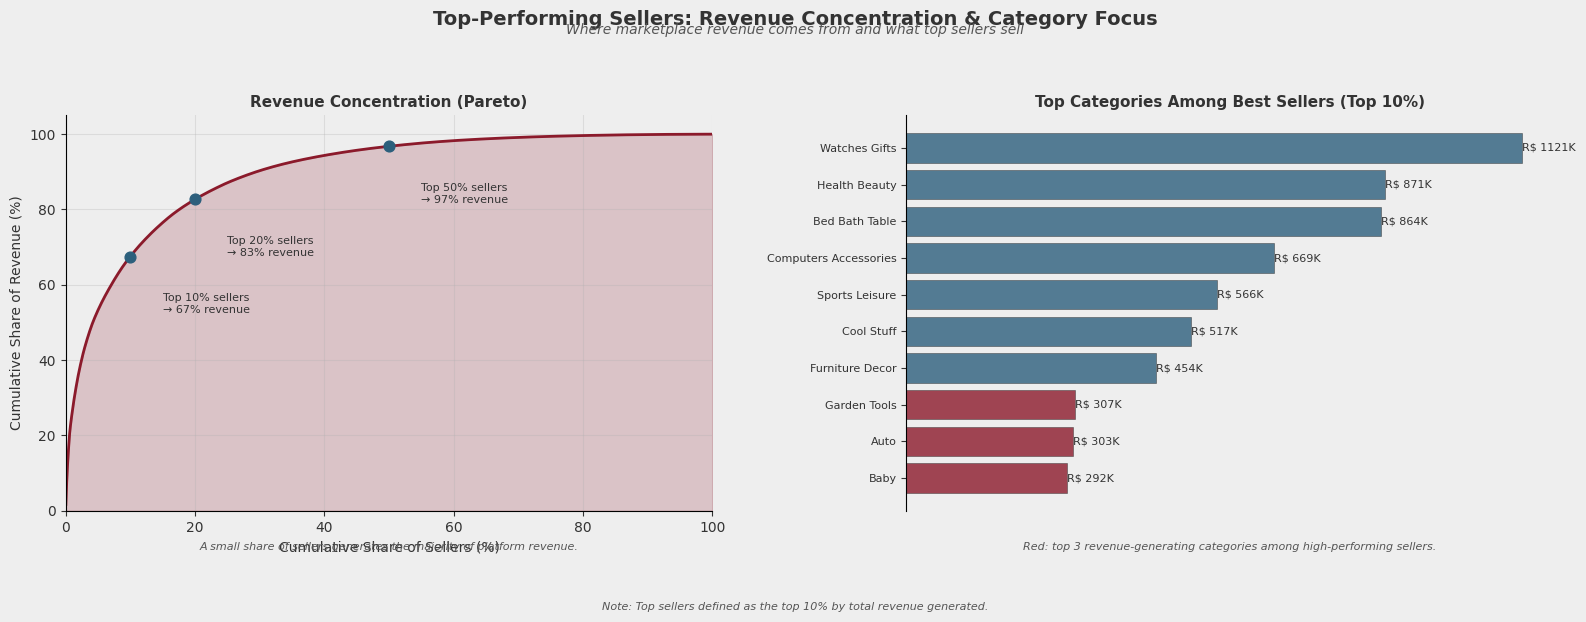

In [89]:
# Seller revenue concentration
seller_revenue = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)
seller_revenue_cum_pct = seller_revenue.cumsum() / seller_revenue.sum() * 100
seller_rank_pct = np.arange(1, len(seller_revenue) + 1) / len(seller_revenue) * 100

# Top 10% seller category distribution
top_sellers = seller_revenue.head(int(len(seller_revenue) * 0.1)).index
top_seller_categories = order_items[order_items['seller_id'].isin(top_sellers)] \
    .merge(products[['product_id', 'product_category_name']], on='product_id') \
    .merge(category_translation, on='product_category_name') \
    .groupby('product_category_name_english')['price'].sum() \
    .sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#EEEEEE')
for ax in [ax1, ax2]:
    ax.set_facecolor('#EEEEEE')

fig.suptitle('Top-Performing Sellers: Revenue Concentration & Category Focus', fontsize=14, fontweight='bold')
fig.text(0.5, 0.94, 'Where marketplace revenue comes from and what top sellers sell',
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Pareto curve
ax1.plot(seller_rank_pct, seller_revenue_cum_pct.values, color='#8B1A2B', linewidth=2)
ax1.fill_between(seller_rank_pct, seller_revenue_cum_pct.values, alpha=0.2, color='#8B1A2B')

for threshold_pct in [10, 20, 50]:
    idx = int(len(seller_revenue) * threshold_pct / 100) - 1
    rev_share = seller_revenue_cum_pct.iloc[idx]
    ax1.scatter(threshold_pct, rev_share, color='#2C5F7C', s=60, zorder=5)
    ax1.annotate(f'Top {threshold_pct}% sellers\n→ {rev_share:.0f}% revenue',
                 xy=(threshold_pct, rev_share),
                 xytext=(threshold_pct + 5, rev_share - 15),
                 fontsize=8, color='#333333')

ax1.set_xlabel('Cumulative Share of Sellers (%)')
ax1.set_ylabel('Cumulative Share of Revenue (%)')
ax1.set_title('Revenue Concentration (Pareto)', fontsize=11, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.5, -0.1, 'A small share of sellers generates the majority of platform revenue.',
         transform=ax1.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Right: Top seller categories
ax2.barh(top_seller_categories.index[::-1],
         top_seller_categories.values[::-1],
         color=['#8B1A2B'] * 3 + ['#2C5F7C'] * 7, alpha=0.8,
         edgecolor='#333333', linewidth=0.4)

for i, (cat, val) in enumerate(zip(top_seller_categories.index[::-1], top_seller_categories.values[::-1])):
    ax2.text(val + 500, i, f'R$ {val/1000:.0f}K', va='center', fontsize=8)

ax2.set_title('Top Categories Among Best Sellers (Top 10%)', fontsize=11, fontweight='bold')
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.set_xticks([])
ax2.set_yticklabels([c.replace('_', ' ').title() for c in top_seller_categories.index[::-1]], fontsize=8)
ax2.text(0.5, -0.1, 'Red: top 3 revenue-generating categories among high-performing sellers.',
         transform=ax2.transAxes, ha='center', fontsize=8, fontstyle='italic', color='#555555')

fig.text(0.5, -0.02,
         'Note: Top sellers defined as the top 10% by total revenue generated.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)
plt.show()

Sol grafik, platformdaki gelir yoğunlaşmasını açıkça ortaya koymaktadır. Satıcıların yalnızca %10'u toplam gelirin büyük bölümünü üretmekte, %50'lik dilim ise neredeyse tüm geliri oluşturmaktadır. Bu klasik Pareto dinamiği, yeni bir pazara girerken geniş bir satıcı tabanı kurmaya çalışmak yerine az sayıda yüksek performanslı satıcıyla başlamanın çok daha verimli olduğunu göstermektedir.
Sağ grafik ise bu başarılı satıcıların hangi kategorilerde yoğunlaştığını göstermektedir. Health Beauty, Watches Gifts ve Bed Bath Table gibi kategoriler öne çıkmaktadır — bu bulgu, soru 2'deki kategori analizi ile tam örtüşmektedir. Yani hem gelir hem de satıcı performansı açısından aynı kategoriler öne çıkmaktadır.

Sonuç olarak pazara giriş stratejisi şu şekilde kurgulanmalıdır: ilk aşamada Health Beauty ve Watches Gifts gibi kanıtlanmış kategorilerde güçlü satıcılarla ortaklık kurulmalı, ikinci aşamada ise bu çekirdek satıcı tabanı genişletilerek platform derinliği artırılmalıdır. Geniş ama zayıf bir satıcı tabanı yerine dar ama güçlü bir başlangıç, hem gelir güvencesi hem de müşteri memnuniyeti açısından çok daha sağlam bir zemin oluşturacaktır.

### 4.8 Question 8: What seasonal demand patterns exist and when is the optimal time to launch?

**Business İmportance:** Yeni bir pazara girmek için doğru zamanı seçmek, ilk izlenimi ve erken büyümeyi doğrudan etkiler. Talebin ne zaman yükseldiğini, hangi kategorilerin hangi dönemde öne çıktığını bilmek; hem lansman tarihinin hem de ilk dönem stok ve kampanya planlamasının veri odaklı biçimde kurgulanmasına olanak tanır.

Bu analizde iki şeyi birlikte sunmayı seçtik: üst grafik genel aylık sipariş hacmini gösterirken, alt heatmap aynı dönemdeki kategori bazlı dağılımı ortaya koyuyor. Bu ikili yapı sayesinde hem "ne zaman?" hem de "ne satılıyor?" sorularını aynı anda yanıtlamak mümkün oluyor.

Üst grafik incelendiğinde Ağustos ayının 10.843 siparişle zirveye ulaştığı görülmektedir. Mayıs ve Temmuz da güçlü aylar olarak öne çıkmaktadır. Buna karşın Eylül ve Ekim belirgin bir düşüş yaşamakta, Aralık ise yılın en düşük ikinci ayı olarak dikkat çekmektedir. Bu durum, Brezilya'nın yaz dönemi olan Aralık-Şubat'ın alışveriş açısından beklentilerin aksine zayıf kaldığını göstermektedir.
Alt heatmap ise bu genel trendi kategori bazında detaylandırmaktadır. Health Beauty ve Bed Bath Table, yılın büyük bölümünde yüksek ve istikrarlı talep sergilemekte; özellikle Mayıs-Ağustos döneminde belirgin biçimde güçlenmektedir. Computers Accessories ise Şubat ayında diğer aylara kıyasla belirgin bir sıçrama göstermektedir — bu durum, okul dönemi başlangıcıyla ilişkilendirilebilir. Garden Tools ve Telephony kategorilerinde ise Eylül-Ekim döneminde keskin düşüşler gözlemlenmektedir.
Tüm bu bulgular değerlendirildiğinde, piyasaya giriş için en uygun dönemin Mart-Mayıs aralığı olduğu görülmektedir. Bu dönem hem talep hacminin yükselişe geçtiği hem de Ağustos zirvesine hazırlanmak için yeterli operasyonel sürenin bulunduğu bir pencere sunmaktadır. Ayrıca Health Beauty ve Bed Bath Table gibi yıl boyu güçlü seyreden kategorilerle başlamak, sezonsal dalgalanmalardan bağımsız istikrarlı bir gelir akışı sağlayacaktır.

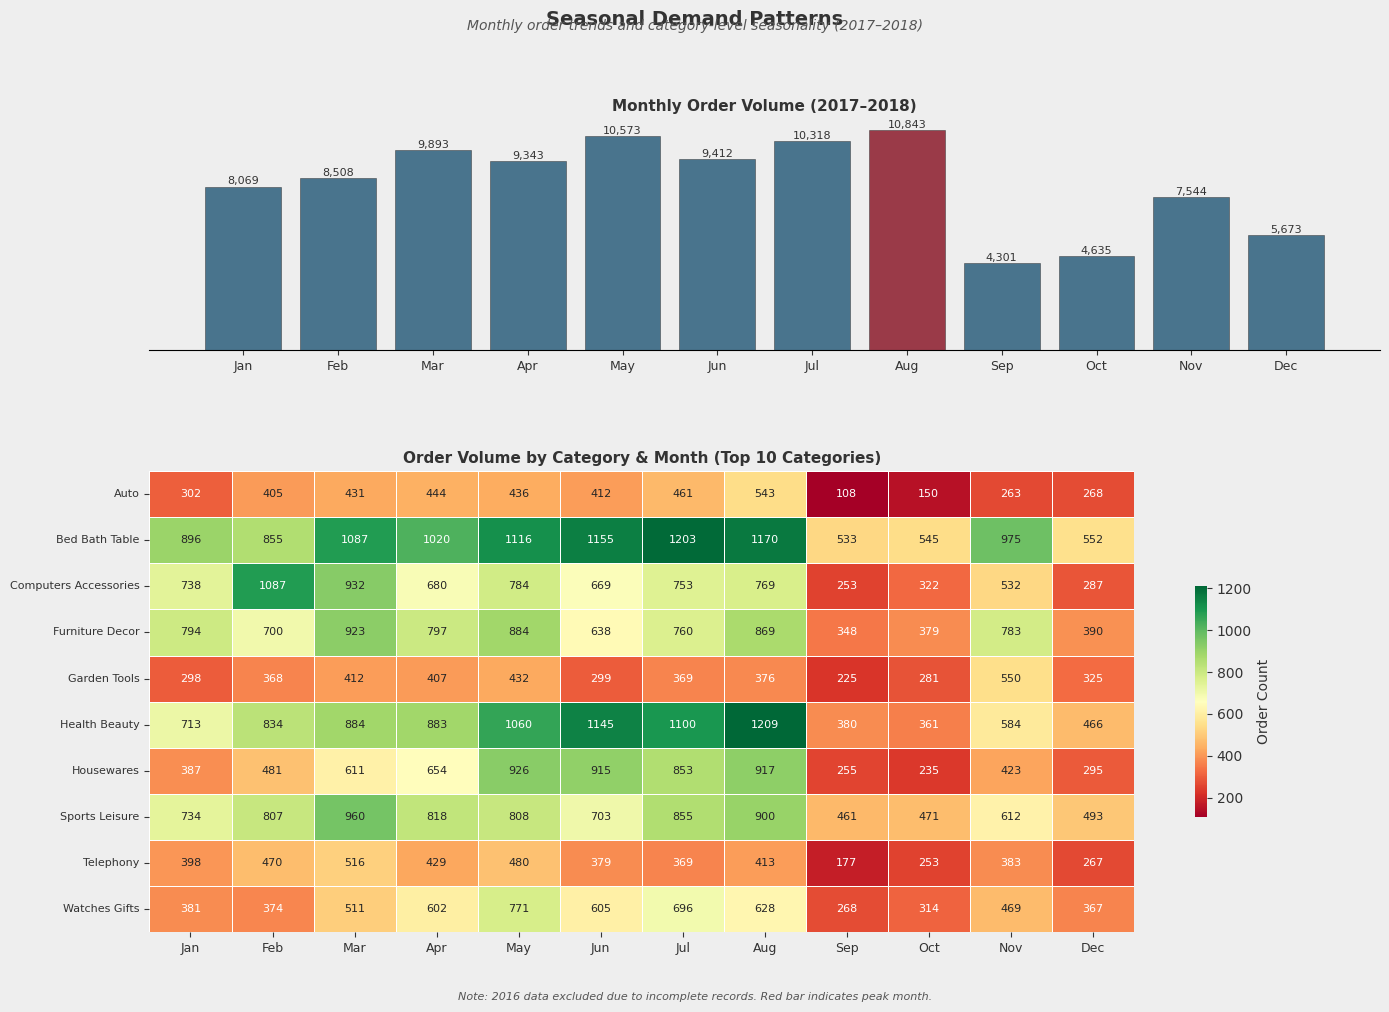

In [90]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['month_num'] = orders['order_purchase_timestamp'].dt.month
orders['year'] = orders['order_purchase_timestamp'].dt.year

# Monthly order volume (2017-2018 only, 2016 incomplete)
monthly_orders = orders[orders['year'].isin([2017, 2018])].groupby('month')['order_id'].count()

# Category by month heatmap
cat_monthly = order_items.merge(products[['product_id', 'product_category_name']], on='product_id') \
    .merge(category_translation, on='product_category_name') \
    .merge(orders[['order_id', 'month_num', 'year']], on='order_id')

cat_monthly = cat_monthly[cat_monthly['year'].isin([2017, 2018])]

top_categories = cat_monthly.groupby('product_category_name_english')['order_id'].count() \
    .sort_values(ascending=False).head(10).index

heatmap_data = cat_monthly[cat_monthly['product_category_name_english'].isin(top_categories)] \
    .groupby(['product_category_name_english', 'month_num'])['order_id'].count().unstack(fill_value=0)

heatmap_data.index = [i.replace('_', ' ').title() for i in heatmap_data.index]
heatmap_data.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]})
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('Seasonal Demand Patterns', fontsize=14, fontweight='bold')
fig.text(0.5, 0.96, 'Monthly order trends and category-level seasonality (2017–2018)',
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Top: Monthly order volume
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_by_month = orders[orders['year'].isin([2017, 2018])].groupby('month_num')['order_id'].count()

bar_colors = ['#8B1A2B' if v == monthly_by_month.max() else '#2C5F7C' for v in monthly_by_month.values]
ax1.bar(range(12), monthly_by_month.values, color=bar_colors, alpha=0.85,
        edgecolor='#333333', linewidth=0.4)

for i, val in enumerate(monthly_by_month.values):
    ax1.text(i, val + 100, f'{val:,}', ha='center', fontsize=8)

ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, fontsize=9)
ax1.set_title('Monthly Order Volume (2017–2018)', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.set_yticks([])

# Bottom: Heatmap
sns.heatmap(heatmap_data, ax=ax2, cmap='RdYlGn', linewidths=0.5,
            linecolor='white', annot=True, fmt='d', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.5, 'label': 'Order Count'})

ax2.set_title('Order Volume by Category & Month (Top 10 Categories)', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=0, labelsize=9)
ax2.tick_params(axis='y', rotation=0, labelsize=8)

fig.text(0.5, -0.01,
         'Note: 2016 data excluded due to incomplete records. Red bar indicates peak month.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.subplots_adjust(hspace=0.35)
plt.show()

Üst grafik incelendiğinde Ağustos ayının 10.843 siparişle zirveye ulaştığı görülmektedir. Mayıs ve Temmuz da güçlü aylar olarak öne çıkmaktadır. Buna karşın Eylül ve Ekim belirgin bir düşüş yaşamakta, Aralık ise yılın en düşük ikinci ayı olarak dikkat çekmektedir. Bu durum, Brezilya'nın yaz dönemi olan Aralık-Şubat'ın alışveriş açısından beklentilerin aksine zayıf kaldığını göstermektedir.
Alt heatmap ise bu genel trendi kategori bazında detaylandırmaktadır. Health Beauty ve Bed Bath Table, yılın büyük bölümünde yüksek ve istikrarlı talep sergilemekte; özellikle Mayıs-Ağustos döneminde belirgin biçimde güçlenmektedir. Computers Accessories ise Şubat ayında diğer aylara kıyasla belirgin bir sıçrama göstermektedir — bu durum, okul dönemi başlangıcıyla ilişkilendirilebilir. Garden Tools ve Telephony kategorilerinde ise Eylül-Ekim döneminde keskin düşüşler gözlemlenmektedir.
Tüm bu bulgular değerlendirildiğinde, piyasaya giriş için en uygun dönemin Mart-Mayıs aralığı olduğu görülmektedir. Bu dönem hem talep hacminin yükselişe geçtiği hem de Ağustos zirvesine hazırlanmak için yeterli operasyonel sürenin bulunduğu bir pencere sunmaktadır. Ayrıca Health Beauty ve Bed Bath Table gibi yıl boyu güçlü seyreden kategorilerle başlamak, sezonsal dalgalanmalardan bağımsız istikrarlı bir gelir akışı sağlayacaktır.

### 4.9 Question 9: Bringing it all together: which states represent the most attractive markets for prioritized expansion?

İş Önemi: Bu analiz, raporun tüm fazlarında elde edilen bulguları tek bir stratejik tabloda bir araya getirmektedir. Pazar büyüklüğü, lojistik güvenilirlik, müşteri memnuniyeti ve gelir potansiyelini aynı anda değerlendirmek; sınırlı kaynakların doğru coğrafyalara yönlendirilmesi için kritik bir öneme sahiptir. Hangi eyalete önce girileceği kararı, yalnızca müşteri sayısına değil; teslimat altyapısının olgunluğuna, mevcut gelir hacmine ve müşteri deneyimi kalitesine birlikte bakılarak verilmelidir.
Bu grafikte dört boyut aynı anda sunulmaktadır: x ekseninde zamanında teslimat oranı, y ekseninde müşteri sayısı (logaritmik ölçek), baloncuk büyüklüğünde toplam gelir ve renkte bölge. Her baloncuğun üzerindeki değer ise o eyaletin ortalama müşteri puanını göstermektedir.

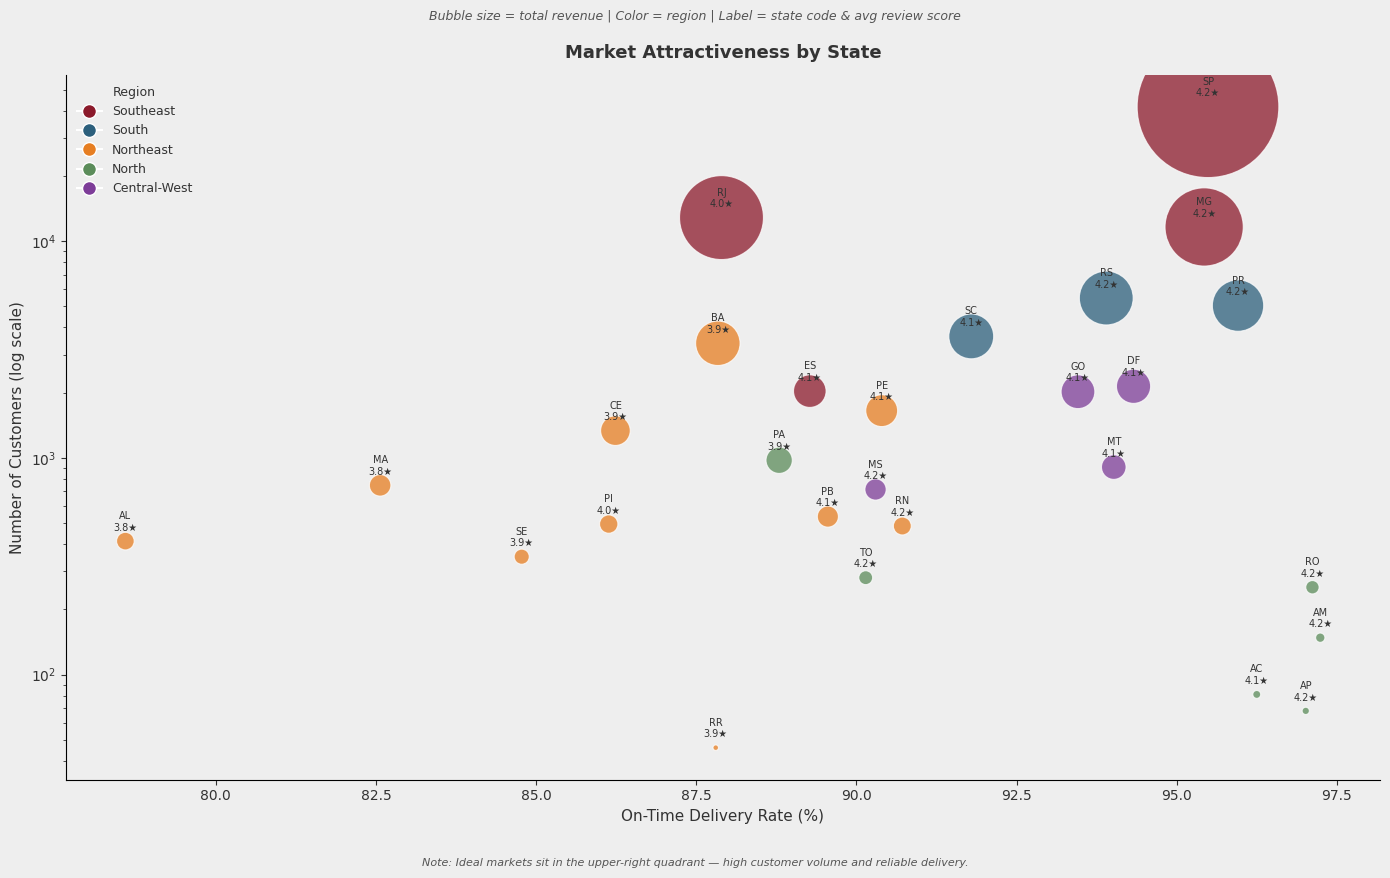

In [100]:
# State-level metrics
state_customers = customers.groupby('customer_state')['customer_id'].count()
state_revenue = order_items.merge(orders[['order_id', 'customer_id']], on='order_id') \
    .merge(customers[['customer_id', 'customer_state']], on='customer_id') \
    .groupby('customer_state')['price'].sum()

state_reviews = orders[orders['order_status'] == 'delivered'] \
    .merge(reviews[['order_id', 'review_score']], on='order_id') \
    .merge(customers[['customer_id', 'customer_state']], on='customer_id') \
    .groupby('customer_state')['review_score'].mean()

state_ontime = delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id') \
    .groupby('customer_state')['on_time'].mean() * 100

region_map = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'RS': 'South', 'SC': 'South', 'PR': 'South',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast',
    'PB': 'Northeast', 'RN': 'Northeast', 'AL': 'Northeast', 'SE': 'Northeast',
    'PI': 'Northeast', 'RR': 'Northeast',
    'AM': 'North', 'PA': 'North', 'RO': 'North', 'AC': 'North',
    'AP': 'North', 'TO': 'North',
    'MT': 'Central-West', 'MS': 'Central-West', 'GO': 'Central-West', 'DF': 'Central-West'
}

region_colors = {
    'Southeast': '#8B1A2B',
    'South': '#2C5F7C',
    'Northeast': '#E67E22',
    'North': '#5B8C5A',
    'Central-West': '#7D3C98'
}

state_df = pd.DataFrame({
    'customers': state_customers,
    'revenue': state_revenue,
    'review_score': state_reviews,
    'on_time_rate': state_ontime
}).dropna()
state_df['region'] = state_df.index.map(region_map)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#EEEEEE')
ax.set_facecolor('#EEEEEE')

for region, group in state_df.groupby('region'):
    ax.scatter(
        group['on_time_rate'],
        group['customers'],
        s=group['revenue'] / 500,
        c=region_colors[region],
        alpha=0.75,
        edgecolors='white',
        linewidth=0.8,
        label=region
    )


for state, row in state_df.iterrows():
    ax.annotate(f"{state}\n{row['review_score']:.1f}★",
                xy=(row['on_time_rate'], row['customers']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points', color='#333333')

ax.set_xlabel('On-Time Delivery Rate (%)', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('Number of Customers (log scale)', fontsize=11)
ax.set_title('Market Attractiveness by State', fontsize=13, fontweight='bold', pad=12)
fig.text(0.5, 0.93, 'Bubble size = total revenue | Color = region | Label = state code & avg review score',
         ha='center', fontsize=9, fontstyle='italic', color='#555555')

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
           markersize=10, label=region)
    for region, color in region_colors.items()
]

ax.legend(handles=legend_elements, title='Region', fontsize=9, 
          framealpha=0, title_fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

fig.text(0.5, -0.01,
         'Note: Ideal markets sit in the upper-right quadrant — high customer volume and reliable delivery.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

Grafik, Brezilya'nın eyalet bazındaki pazar çekiciliğini dört boyutlu olarak ortaya koymaktadır. Sağ üst köşe — yüksek müşteri hacmi ve yüksek zamanında teslimat oranının kesiştiği alan — en öncelikli giriş noktalarını temsil etmektedir.
Bu açıdan bakıldığında São Paulo (SP) tartışmasız ilk sıradadır. Hem en yüksek müşteri sayısına hem de en büyük gelir hacmine sahip olan SP, %95,5 zamanında teslimat oranı ve 4.2 müşteri puanıyla operasyonel olgunluğunu da kanıtlamaktadır. Minas Gerais (MG) ve Paraná (PR) de yüksek müşteri hacmi, güçlü teslimat performansı ve iyi müşteri puanlarıyla ikinci öncelik grubunda yer almaktadır.
Rio de Janeiro (RJ) ise farklı bir profil sergilemektedir. Müşteri sayısı açısından SP'den sonra gelmesine karşın, %87,9 zamanında teslimat oranıyla güneydoğu eyaletleri arasında en zayıf lojistik performansı göstermektedir. Bu durum, RJ'de güçlü bir lojistik ortaklığı kurulmadan agresif bir büyüme stratejisi izlenmemesi gerektiğine işaret etmektedir.
Rio Grande do Sul (RS) ve Santa Catarina (SC) güney bölgesinde öne çıkan eyaletlerdir. Her iki eyalet de dengeli müşteri hacmi, yüksek teslimat güvenilirliği ve iyi müşteri puanlarıyla orta vadeli genişleme için cazip bir profil sunmaktadır.
Kuzeydoğu bölgesinde Bahia (BA) ve Pernambuco (PE) müşteri sayısı açısından bölgenin en büyük pazarlarıdır; ancak her ikisi de %88–90 bandındaki zamanında teslimat oranlarıyla lojistik iyileştirme gerektirmektedir. Bu eyaletler, yerel lojistik altyapısı güçlendirildikten sonra ele alınması gereken üçüncü öncelik grubunu oluşturmaktadır.
Sonuç olarak pazar giriş stratejisi üç aşamada kurgulanmalıdır. İlk aşamada SP, MG ve PR'ye odaklanılmalı; güçlü lojistik altyapısı ve büyük müşteri tabanı bu eyaletleri en az riskli ve en yüksek getirili giriş noktaları yapmaktadır. İkinci aşamada RS, SC ve DF gibi dengeli profilli eyaletlere genişlenmelidir. Üçüncü aşamada ise BA ve PE başta olmak üzere kuzeydoğu eyaletleri, bölgesel lojistik yatırımlarıyla birlikte ele alınmalıdır. Bu aşamalı yaklaşım, hem operasyonel riski minimize eder hem de her aşamada elde edilen gelirin bir sonraki aşamayı finanse etmesine olanak tanır.

### Limitations

1. **Temporal Gap:** The dataset predates the COVID-19 pandemic, 
   which significantly accelerated e-commerce adoption in Brazil. 
   Post-pandemic consumer expectations for delivery speed and 
   digital payment options (particularly PIX, launched in 2020) 
   have evolved beyond what this dataset reflects.

2. **Recommendation:** TrendCommerce should supplement this 
   historical analysis with current market research to validate 
   findings against post-pandemic realities. However, the 
   structural insights—geographic priorities, category preferences, 
   logistics challenges—provide a reliable foundation for 
   strategic planning.

# References

EMARKETER (2025) Latin America reclaims its spot as the world’s fastest-growing ecommerce market. Available at: https://www.emarketer.com/content/latin-america-ecommerce-forecast-2025-growth-outlook-argentina-brazil-mexico
 (Accessed: 13 May 2026).
McKinsey & Company (2025) What is e-commerce? Available at: https://www.mckinsey.com/featured-insights/mckinsey-explainers/what-is-e-commerce
 (Accessed: 13 May 2026).
 Market Data Forecast (2026) Latin America E-Commerce Market Size, Share, 2034. Available at: https://www.marketdataforecast.com/market-reports/latin-america-e-commerce-market
 (Accessed: 13 May 2026).
 Deloitte (2024) Global Powers of Retailing 2024: Navigating the New Digital Consumer. Available at: https://www2.deloitte.com/global/en/pages/consumer-business/articles/global-powers-of-retailing.html
 (Accessed: 14 May 2026).
Laudon, K.C. and Traver, C.G. (2023) E-commerce 2023–2024: Business, Technology, Society. 18th edn. Harlow: Pearson.
Baldauf, C. (2024) Logistics and Customer Behavior in Online and Omnichannel Retail: A Systematic Review. Available at: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4756771
 (Accessed: 14 May 2026).
Krumme, C., Llorente, A., Cebrián, M., Pentland, A. and Moro, E. (2013) The predictability of consumer visitation patterns. Available at: https://arxiv.org/abs/1305.1120
 (Accessed: 14 May 2026).
Srijan, S. and Rajagopalan, I.R. (2024) 'Best Practices for Handling Missing Data', Annals of Surgical Oncology, 31, pp. 12–13. doi: 10.1245/s10434-023-14471-7. 
dLocal (2023) The power of installment payments in Latin America. Available at: https://www.dlocal.com/blog/markets-and-consumers/the-power-of-installment-payments-in-latin-america/ (Accessed: 16 May 2026).

J.P. Morgan (n.d.) LATAM's payments landscape is evolving quickly. Available at: https://www.jpmorgan.com/payments/payments-unbound/magazine/articles/latam-payment-landscape-evolving-quickly (Accessed: 16 May 2026).
